In [38]:
%load_ext autoreload
%autoreload 2

from mtpy import MT, MTData

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [28]:
fn = r"C:\Users\jpeacock\OneDrive - DOI\EDI_FILES\Transect1_Remote9_E.edi"

In [30]:
mt_obj = MT()
mt_obj.read(fn)

In [11]:
mt_obj.survey_metadata.citation_journal.url

In [6]:
import pandas as pd

In [31]:
df = pd.read_csv(r"c:\Users\jpeacock\OneDrive - DOI\EDI_FILES\edi_file_summary_2026_03_06_failed.csv")

In [32]:
df.head()

,survey,station,latitude,longitude,file_created,filename,period_min,period_max,has_impedance,has_tipper,note
0,NaN,NaN,NaN,NaN,NaN,.edi,NaN,NaN,NaN,NaN,Could not read: ''
1,0,SA225_2,-28.501110,134.476210,1.769725e+09,bad_edi.edi,8.000000,16384.041943,True,True,NaN
2,0,Remote_101,38.502139,-118.253306,1.769725e+09,bridge_Remote_3.edi,0.000100,2912.710720,True,True,NaN
3,0,Remote_102,38.502139,-118.253306,1.769725e+09,bridge_Remote_4.edi,0.000100,2912.710720,True,True,NaN
4,Clearlake2022,cl407,38.888569,-122.651931,1.769725e+09,cl407.edi,0.001143,1514.701236,True,True,NaN


In [33]:
import pandas as pd

# Work on a copy to avoid side effects
df = df.copy()

# Ensure types are consistent
df['station'] = df['station'].astype(str)  # avoid 004 vs 4 mismatches
df['file_created'] = pd.to_numeric(df['file_created'], errors='coerce')

# Remove rows with missing keys or file_created (e.g., your first all-NaN row)
df_clean = df.dropna(subset=['station', 'latitude', 'longitude', 'file_created'])

# Index of the row with the largest file_created per (station, lat, lon)
idx = (
    df_clean
    .groupby(['station', 'latitude', 'longitude'])['file_created']
    .idxmax()
)

# Select those full rows, sorted nicely
df_latest = (
    df_clean.loc[idx]
            .sort_values(['station', 'latitude', 'longitude'])
            .reset_index(drop=True)
)

# df_latest is your new dataframe with one row per duplicate group


In [34]:
df_latest

,survey,station,latitude,longitude,file_created,filename,period_min,period_max,has_impedance,has_tipper,note
0,0,L1X12,0.000000,0.000000,1.769725e+09,L1-12.edi,1.973944,2621.231979,True,False,NaN
1,0,L1X24,0.000000,0.000000,1.769725e+09,L1-24.edi,0.009775,2621.231979,True,False,NaN
2,0,L1X28,0.000000,0.000000,1.769725e+09,L1-28.edi,0.009775,655.307995,True,False,NaN
3,0,L1X29,0.000000,0.000000,1.769725e+09,L1-29.edi,0.009775,655.307995,True,False,NaN
4,0,L1X61A,0.000000,0.000000,1.769725e+09,L1-61.edi,0.009775,655.307995,True,False,NaN
...,...,...,...,...,...,...,...,...,...,...,...
255,0,se_123_20M,40.358600,-119.388233,1.763073e+09,san_emidio_0123_20M.edi,0.004339,1191.568462,True,True,NaN
256,0,um102,45.562222,-118.723889,1.763071e+09,um102_1.edi,0.001302,1023.000007,True,False,NaN
257,0,um106,45.746111,-118.462500,1.769725e+09,um106_1.edi,0.001302,1023.000007,True,False,NaN
258,0,um113,45.609722,-118.742222,1.763071e+09,um113_1.edi,0.001302,1023.000007,True,False,NaN


In [35]:
df_latest_original = pd.read_csv(r"c:\Users\jpeacock\OneDrive - DOI\EDI_FILES\edi_file_summary_latest_2026_03_06.csv")
df_latest_all = pd.concat([df_latest_original, df_latest], ignore_index=True).drop_duplicates(subset=['station', 'latitude', 'longitude'], keep='last').reset_index(drop=True)
df_latest_all.to_csv(r"c:\Users\jpeacock\OneDrive - DOI\EDI_FILES\edi_file_summary_latest_2026_03_06_all.csv", index=False)

In [36]:
import shutil
from pathlib import Path

edi_path = Path(r"c:\Users\jpeacock\OneDrive - DOI\EDI_FILES")
latest_dir = edi_path / "latest_files"
if not latest_dir.exists():
    latest_dir.mkdir(exist_ok=True)

for row in df_latest.itertuples():
    src = edi_path / row.filename
    dst = latest_dir / row.filename
    shutil.copy(src, dst)

In [16]:

df_missing = df[
    df[['station', 'latitude', 'longitude']].isna().any(axis=1)
].copy()
df_missing.to_csv(r"c:\Users\jpeacock\OneDrive - DOI\EDI_FILES\edi_file_summary_missing_keys_2026_03_06.csv", index=False)

In [37]:
df_latest_all.shape

(9376, 11)

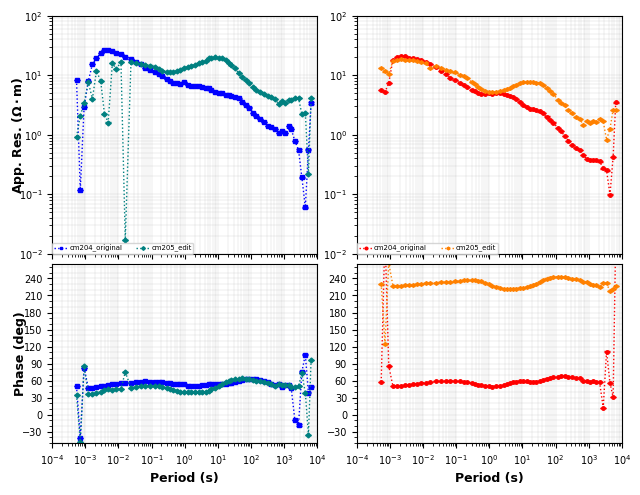

In [51]:
m1 = MT()
m1.read(r"c:\Users\jpeacock\OneDrive - DOI\MTData\CM2025\EDI_Files_geographic_north\cm204_rotated.edi")

m2 = MT()
m2.read(r"c:\Users\jpeacock\OneDrive - DOI\MTData\CM2025\mth5\EDI_Files_aurora_geomag_rr_coherence\cm205.edi")

md = MTData()
md.add_station(m1, survey="original")
md.add_station(m2, survey="edit")

pr = md.plot_mt_response(list(md.keys()), plot_style="compare")

In [52]:
need_to_rotate = Path(r"c:\Users\jpeacock\OneDrive - DOI\MTData\CM2025\EDI_Files_aurora")

In [53]:
for fn in need_to_rotate.glob("*.edi"):
    print(f"Rotating {fn.name}...")
    mt = MT()
    mt.read(fn)
    mt.rotate(-12.6)
    mt.write(fn.parent / f"{fn.stem}_rotated.edi")

Rotating cm205.edi...
26:03:09T15:01:59 | INFO | line:389 |mtpy.core.mt | rotate | Rotated transfer function by: -12.600 degrees clockwise in reference frame NED.
Rotating cm206.edi...
26:03:09T15:02:00 | INFO | line:389 |mtpy.core.mt | rotate | Rotated transfer function by: -12.600 degrees clockwise in reference frame NED.
Rotating cm207.edi...
26:03:09T15:02:01 | INFO | line:389 |mtpy.core.mt | rotate | Rotated transfer function by: -12.600 degrees clockwise in reference frame NED.
Rotating cm209.edi...
26:03:09T15:02:02 | INFO | line:389 |mtpy.core.mt | rotate | Rotated transfer function by: -12.600 degrees clockwise in reference frame NED.
Rotating cm228.edi...
26:03:09T15:02:03 | INFO | line:389 |mtpy.core.mt | rotate | Rotated transfer function by: -12.600 degrees clockwise in reference frame NED.
Rotating cm230.edi...
26:03:09T15:02:04 | INFO | line:389 |mtpy.core.mt | rotate | Rotated transfer function by: -12.600 degrees clockwise in reference frame NED.
